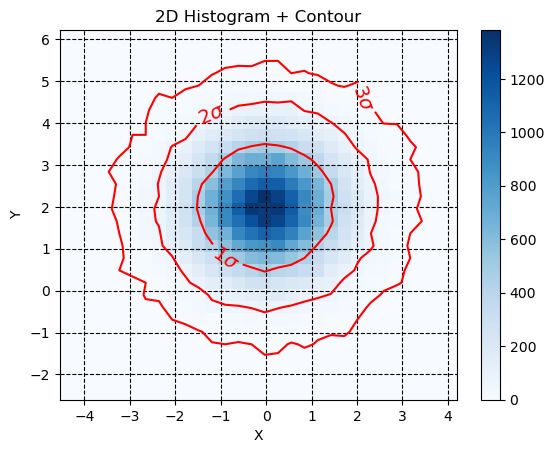

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
x = np.random.normal(0, 1, 100000)
y = np.random.normal(2, 1, 100000)

counts, xedges, yedges, im = plt.hist2d(x, y, bins=30, cmap="Blues")
plt.colorbar()

# Overlay contours
#X, Y = np.meshgrid((xedges[:-1] + xedges[1:])/2,
#                   (yedges[:-1] + yedges[1:])/2)
#plt.contour(X, Y, counts.T, colors='red')


# Bin centers
X, Y = np.meshgrid((xedges[:-1] + xedges[1:])/2,
                   (yedges[:-1] + yedges[1:])/2)

#X, Y = (xedges[:-1] + xedges[1:])/2, (yedges[:-1] + yedges[1:])/2
#X, Y = xedges[:-1], yedges[:-1]

pdf = counts / counts.sum()
sorted_pdf = np.sort(pdf.flatten())[::-1]
cumulative = np.cumsum(sorted_pdf)

# Find levels corresponding to 68%, 95%, 99.7%
levels = []
for p in [0.68, 0.95, 0.997]:
    # Level where cumulative sum first exceeds p
    level = sorted_pdf[cumulative <= p].min()
    levels.append(level)

# Plot contour with sigma levels
contours = plt.contour(X, Y, counts.T / counts.sum(), levels=levels[::-1], colors='red')
plt.clabel(contours, fmt={level: fr'{sigma}$\sigma$' for level, sigma in zip(levels, [1, 2, 3])}, colors='r', fontsize=14)


#plt.hist2d(x,y, bins=30, cmap="Blues")
#plt.scatter(x, y, s=5, color='k', alpha=0.5)

plt.title("2D Histogram + Contour")
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', color='k')
plt.show()
